# Semi-Commercial Classification with Height-Based Results

This notebook applies the semi-commercial post-processing rules to the final classifications produced by the height-enhanced model workflow.

**Input**
- Final building classifications from the height-enhanced workflow.
- Supporting OSM, POI, and land-use information.

**Output**
- Updated semi-commercial classifications and subtypes.

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import warnings
import sys

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Directory config ──────────────────────────────────────────────────────────
ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR  = os.path.join(ROOT_DIR, 'data')
OUT_DIR   = os.path.join(DATA_DIR, 'final')
PROC_DIR  = os.path.join(DATA_DIR, 'processed')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)

# building file needed to validate that all building IDs are present in the final output
UNTAGGED_BUILDING_FILE = os.path.join(PROC_DIR, 'germany_buildings_feature_engineered_heights.parquet')
CLASSIFIED_BUILDING_FILE = os.path.join(OUT_DIR, 'germany_buildings_classified_final_height.parquet')
POI_FILE = os.path.join(DATA_DIR, 'processed', 'germany_pois_mapped.parquet')

SEMI_COMM_FILE = os.path.join(OUT_DIR, 'germany_buildings_classified_semi_comm_height.parquet')

print(f"Untagged building file : {UNTAGGED_BUILDING_FILE}")
print(f"Classified building file   : {CLASSIFIED_BUILDING_FILE}")

Untagged building file : /fast/home/o-olajuyigbe/osm_project/data/processed/germany_buildings_feature_engineered_heights.parquet
Classified building file   : /fast/home/o-olajuyigbe/osm_project/data/final/germany_buildings_classified_final_height.parquet


In [2]:
gdf_untagged = gpd.read_parquet(
     UNTAGGED_BUILDING_FILE,
     columns=['id', 'geometry', 'tag_l1', 'tag_l2',  'building_l1', 'building_l2',
               'buse_l1', 'buse_l2', 'amenity_l1', 'amenity_l2', 'shop_l1', 'shop_l2',
               'landuse_l1', 'landuse_l2', 'craft', 'office', 'shop']   
 )
gdf_poi = gpd.read_parquet(POI_FILE)
gdf_classified = pd.read_parquet(CLASSIFIED_BUILDING_FILE)

gdf_bldg = gdf_classified.merge(gdf_untagged.set_index('id'), left_index=True, right_index=True, how='left')
gdf_bldg = gpd.GeoDataFrame(gdf_bldg, geometry='geometry', crs=gdf_untagged.crs
)
print(f"Buildings shape: {gdf_bldg.shape}")

Buildings shape: (38802372, 21)


### Rule 1 - Direct Tags (craft, office, shop)

In [3]:
# Initialize columns for both subtype and the algorithmic rule source
gdf_bldg['semi_commercial_type'] = None
gdf_bldg['rule_source'] = None

# Base mask for buildings predicted as residential
is_res = gdf_bldg['final_l1'] == 'residential'

# ── Rule 1: Direct feature engineering tags ──
# Apply direct tag rules (If a building has multiple, the last one evaluated takes precedence.
mask_craft = is_res & gdf_bldg['craft'].notna()
gdf_bldg.loc[mask_craft, 'semi_commercial_type'] = 'residential_commercial'
gdf_bldg.loc[mask_craft, 'rule_source'] = 'Rule 1: Direct Tags (craft)'

mask_shop = is_res & gdf_bldg['shop'].notna()
gdf_bldg.loc[mask_shop, 'semi_commercial_type'] = 'residential_retail'
gdf_bldg.loc[mask_shop, 'rule_source'] = 'Rule 1: Direct Tags (shop)'

mask_office = is_res & gdf_bldg['office'].notna()
gdf_bldg.loc[mask_office, 'semi_commercial_type'] = 'residential_office'
gdf_bldg.loc[mask_office, 'rule_source'] = 'Rule 1: Direct Tags (office)'



print("Tally after Rule 1:")
print(gdf_bldg['rule_source'].value_counts().to_string())
print(gdf_bldg['semi_commercial_type'].value_counts().to_string())

Tally after Rule 1:
rule_source
Rule 1: Direct Tags (office)    3659
Rule 1: Direct Tags (craft)     3303
Rule 1: Direct Tags (shop)      3286
semi_commercial_type
residential_office        3659
residential_commercial    3303
residential_retail        3286


### Rule 2 - L1/L2 Conflicting Tags

In [ ]:

print("Running Rule 2 (Residential)...")

# Base mask: only evaluate rows that are residential and haven't been tagged yet
base_mask = (gdf_bldg['final_l1'] == 'residential') & gdf_bldg['rule_source'].isna()

# Keep track of rows that STILL need checking as we loop through the columns
still_looking = base_mask.copy()

l1_cols = ['amenity_l1', 'tag_l1', 'buse_l1', 'building_l1']
l2_cols = ['amenity_l2', 'tag_l2', 'buse_l2', 'building_l2']

for c1, c2 in zip(l1_cols, l2_cols):
    # Only look at rows that haven't been matched yet
    valid_mask = (
        still_looking & 
        gdf_bldg[c1].notna() & 
        (gdf_bldg[c1].isin(['commercial', 'civic', 'industrial'])) 
    )
    
    if not valid_mask.any():
        continue # Skip to next column pair if nothing matches here
        
    # --- Condition A: v1 == 'commercial' ---
    is_comm = valid_mask & (gdf_bldg[c1] == 'commercial')
    has_l2 = is_comm & gdf_bldg[c2].notna()
    no_l2 = is_comm & gdf_bldg[c2].isna()
    
    # Assign subtypes
    gdf_bldg.loc[has_l2, 'semi_commercial_type'] = "residential_" + gdf_bldg.loc[has_l2, c2].astype(str)
    gdf_bldg.loc[no_l2, 'semi_commercial_type'] = "residential_commercial"
    gdf_bldg.loc[is_comm, 'rule_source'] = f"Rule 2: L1/L2 Conflict ({c1}=commercial)"
    
    # --- Condition B: v1 == 'civic' ---
    is_civic = valid_mask & (gdf_bldg[c1] == 'civic')
    gdf_bldg.loc[is_civic, 'semi_commercial_type'] = "residential_civic"
    gdf_bldg.loc[is_civic, 'rule_source'] = f"Rule 2: L1/L2 Conflict ({c1}=civic)"
    
    # --- Condition C: Everything else (not commercial, not civic, not military, not residential) ---
    is_other = valid_mask & ~is_comm & ~is_civic
    gdf_bldg.loc[is_other, 'semi_commercial_type'] = "residential_commercial"
    # Construct the rule source string dynamically using the actual value in c1
    gdf_bldg.loc[is_other, 'rule_source'] = "Rule 2: L1/L2 Conflict (" + c1 + "=" + gdf_bldg.loc[is_other, c1].astype(str) + ")"
    
    # --- Update tracking mask ---
    still_looking = still_looking & ~valid_mask
    
    if not still_looking.any():
        break

print("\nTally after Rule 2:")
print(gdf_bldg['rule_source'].value_counts().to_string())
print("\nSubtypes after Rule 2:")
print(gdf_bldg['semi_commercial_type'].value_counts().to_string())

Running Rule 2 (Residential)...



Tally after Rule 2:
rule_source
Rule 2: L1/L2 Conflict (amenity_l1=civic)         4402
Rule 1: Direct Tags (office)                      3659
Rule 1: Direct Tags (craft)                       3303
Rule 1: Direct Tags (shop)                        3286
Rule 2: L1/L2 Conflict (amenity_l1=commercial)    2100
Rule 2: L1/L2 Conflict (tag_l1=commercial)        1971
Rule 2: L1/L2 Conflict (tag_l1=civic)             1300
Rule 2: L1/L2 Conflict (buse_l1=commercial)        611
Rule 2: L1/L2 Conflict (tag_l1=industrial)         210
Rule 2: L1/L2 Conflict (buse_l1=civic)             157
Rule 2: L1/L2 Conflict (buse_l1=industrial)        131

Subtypes after Rule 2:
semi_commercial_type
residential_civic            5859
residential_office           4115
residential_commercial       4017
residential_retail           3885
residential_food_drink       2054
residential_accommodation    1141
residential_other_service      59


In [5]:

print("Running Rule 2 (Commercial buildings with conflicting residential tags)...")

# Base mask: only evaluate rows that are residential and haven't been tagged yet
base_mask = (gdf_bldg['final_l1'] == 'commercial') & gdf_bldg['rule_source'].isna()
still_looking = base_mask.copy()

l1_cols = ['amenity_l1', 'tag_l1', 'buse_l1', 'building_l1']
l2_cols = ['amenity_l2', 'tag_l2', 'buse_l2', 'building_l2']

for c1, c2 in zip(l1_cols, l2_cols):
    # Only look at rows that haven't been matched yet
    matched = still_looking & (gdf_bldg[c1] == 'residential') 
    
    if not matched.any():
        continue # Skip to next column pair if nothing matches here
        
    commercial_l2 = gdf_bldg.loc[matched, "final_l2"].astype("object")
    specific_l2 = commercial_l2.notna() & commercial_l2.astype(str).ne("commercial")

    specific_idx = commercial_l2.index[specific_l2]
    fallback_idx = commercial_l2.index[~specific_l2]

    gdf_bldg.loc[specific_idx, "semi_commercial_type"] = (
        "residential_" + commercial_l2.loc[specific_idx].astype(str)
    )
    gdf_bldg.loc[fallback_idx, "semi_commercial_type"] = "residential_commercial"

    gdf_bldg.loc[matched, "rule_source"] = (
        f"Rule 2: Commercial/Residential Conflict ({c1}=residential)"
    )

    still_looking &= ~matched

    if not still_looking.any():
        break

mask_rule2 = gdf_bldg["rule_source"].str.startswith(
    "Rule 2:", na=False
)


print("\nTally after Rule 2:")
print(gdf_bldg['rule_source'].value_counts().to_string())
print("\nSubtypes after Rule 2:")
print(gdf_bldg['semi_commercial_type'].value_counts().to_string())

Running Rule 2 (Commercial buildings with conflicting residential tags)...



Tally after Rule 2:
rule_source
Rule 2: L1/L2 Conflict (amenity_l1=civic)                        4402
Rule 1: Direct Tags (office)                                     3659
Rule 1: Direct Tags (craft)                                      3303
Rule 1: Direct Tags (shop)                                       3286
Rule 2: L1/L2 Conflict (amenity_l1=commercial)                   2100
Rule 2: L1/L2 Conflict (tag_l1=commercial)                       1971
Rule 2: L1/L2 Conflict (tag_l1=civic)                            1300
Rule 2: L1/L2 Conflict (buse_l1=commercial)                       611
Rule 2: Commercial/Residential Conflict (tag_l1=residential)      443
Rule 2: Commercial/Residential Conflict (buse_l1=residential)     227
Rule 2: L1/L2 Conflict (tag_l1=industrial)                        210
Rule 2: L1/L2 Conflict (buse_l1=civic)                            157
Rule 2: L1/L2 Conflict (buse_l1=industrial)                       131

Subtypes after Rule 2:
semi_commercial_type
residential_

#### Rule 3- POI Spatial Intersection

In [ ]:
# Filter down to buildings that are residential and STILL have no semi-commercial tag
mask_needs_poi_check = (gdf_bldg['final_l1'] == 'residential') & gdf_bldg['rule_source'].isna()
bldgs_to_check = gdf_bldg.loc[mask_needs_poi_check, ['geometry']]

print(f"Running spatial join for {len(bldgs_to_check)} remaining residential buildings against {len(gdf_poi)} POIs...")

if not bldgs_to_check.empty:
    # ── ALIGN CRS HERE ──
    if bldgs_to_check.crs != gdf_poi.crs:
        print(f"Aligning CRS: Reprojecting POIs from {gdf_poi.crs} to {bldgs_to_check.crs}")
        gdf_poi_aligned = gdf_poi.to_crs(bldgs_to_check.crs)
    else:
        gdf_poi_aligned = gdf_poi
    
    # Find intersecting buildings and POIs
    # NOTE: We now include 'poi_l1' and 'poi_l2' so we can use them for the subtype logic
    intersecting = gpd.sjoin(
        bldgs_to_check, 
        gdf_poi_aligned[['geometry', 'poi_l1', 'poi_l2']],  
        how='inner', 
        predicate='intersects'
    )
    
    # Prefer rows where poi_l2 exists (more specific) over rows where it doesn't
    # Sort so that non-null l2 rows come first, then deduplicate keeping first
    intersecting = (
        intersecting
        .assign(_has_l2=intersecting['poi_l2'].notna())
        .sort_values('_has_l2', ascending=False)
        .drop(columns='_has_l2')
    )

    # A single building might intersect multiple POIs. We keep the first one to avoid duplicate rows.
    intersecting = intersecting[~intersecting.index.duplicated(keep='first')]
    
    # ── Vectorized Subtype Logic ──
    # Set default fallback
    intersecting['calculated_subtype'] = 'residential_commercial'
    
    # Handle 'civic'
    mask_civic = intersecting['poi_l1'] == 'civic'
    intersecting.loc[mask_civic, 'calculated_subtype'] = 'residential_civic'
    
    # Handle 'commercial'
    mask_comm = intersecting['poi_l1'] == 'commercial'
    mask_has_l2 = mask_comm & intersecting['poi_l2'].notna()
    
   
    intersecting.loc[mask_comm & ~mask_has_l2, 'calculated_subtype'] = 'residential_commercial'
    intersecting.loc[mask_has_l2, 'calculated_subtype'] = "residential_" + intersecting.loc[mask_has_l2, 'poi_l2'].astype(str)
    
    # Map the calculated subtypes back to the main building dataframe
    # Using the indexes of the buildings that actually intersected
    valid_indexes = intersecting.index
    
    gdf_bldg.loc[valid_indexes, 'semi_commercial_type'] = intersecting['calculated_subtype']
    gdf_bldg.loc[valid_indexes, 'rule_source'] = 'Rule 3: POI Spatial Intersection'

print(f"Semi-commercial tally after Rule 3 (POI Intersections):")
print(gdf_bldg['rule_source'].value_counts().to_string())
print(gdf_bldg['semi_commercial_type'].value_counts().to_string())

print(f"\nSubtype breakdown from Rule 3:")
mask_rule3 = gdf_bldg['rule_source'] == 'Rule 3: POI Spatial Intersection'
print(gdf_bldg.loc[mask_rule3, 'semi_commercial_type'].value_counts().to_string())

Running spatial join for 20958491 remaining residential buildings against 879768 POIs...
Semi-commercial tally after Rule 3 (POI Intersections):
rule_source
Rule 3: POI Spatial Intersection                                 276967
Rule 2: L1/L2 Conflict (amenity_l1=civic)                          4402
Rule 1: Direct Tags (office)                                       3659
Rule 1: Direct Tags (craft)                                        3303
Rule 1: Direct Tags (shop)                                         3286
Rule 2: L1/L2 Conflict (amenity_l1=commercial)                     2100
Rule 2: L1/L2 Conflict (tag_l1=commercial)                         1971
Rule 2: L1/L2 Conflict (tag_l1=civic)                              1300
Rule 2: L1/L2 Conflict (buse_l1=commercial)                         611
Rule 2: Commercial/Residential Conflict (tag_l1=residential)        443
Rule 2: Commercial/Residential Conflict (buse_l1=residential)       227
Rule 2: L1/L2 Conflict (tag_l1=industrial)         

Rule 4- Residential Buildings in Commercial Landuse

In [7]:
# Residential building in commercial area
mask_landuse_base = (
    (gdf_bldg['final_l1'] == 'residential') & 
    (gdf_bldg['landuse_l1'].isin(['commercial', 'semi_commercial'])) & 
    gdf_bldg['rule_source'].isna()
)

# Sub-mask 1: Specifically Retail
mask_retail = mask_landuse_base & (gdf_bldg['landuse_l2'] == 'retail')
mask_office = mask_landuse_base & (gdf_bldg['landuse_l2'] == 'office')

# Sub-mask 2: General Commercial (everything in the base mask that isn't retail)
mask_other_comm = mask_landuse_base & ~mask_retail & ~mask_office

# Assign Retail
gdf_bldg.loc[mask_retail, 'semi_commercial_type'] = 'residential_retail'
gdf_bldg.loc[mask_retail, 'rule_source'] = 'Rule 4: Commercial Landuse (retail)'

# Assign Office
gdf_bldg.loc[mask_office, 'semi_commercial_type'] = 'residential_office'
gdf_bldg.loc[mask_office, 'rule_source'] = 'Rule 4: Commercial Landuse (office)'

# Assign General Commercial
gdf_bldg.loc[mask_other_comm, 'semi_commercial_type'] = 'residential_commercial'
gdf_bldg.loc[mask_other_comm, 'rule_source'] = 'Rule 4: Commercial Landuse'


# ── Update final_l1 to reflect semi-commercial status ──
is_semi_commercial = gdf_bldg['rule_source'].notna()
gdf_bldg.loc[is_semi_commercial, 'final_l1'] = 'semi_commercial'


# ── Print Summaries ──
print("\n" + "="*50)
print("FINAL RULE SOURCE TRACKING")
print("="*50)
print(gdf_bldg['rule_source'].value_counts(dropna=True))

print("\n" + "="*50)
print("FINAL SUBTYPES BREAKDOWN")
print("="*50)
print(gdf_bldg['semi_commercial_type'].value_counts(dropna=True))


FINAL RULE SOURCE TRACKING
rule_source
Rule 3: POI Spatial Intersection                                 276967
Rule 4: Commercial Landuse                                        32826
Rule 4: Commercial Landuse (retail)                               14589
Rule 2: L1/L2 Conflict (amenity_l1=civic)                          4402
Rule 1: Direct Tags (office)                                       3659
Rule 1: Direct Tags (craft)                                        3303
Rule 1: Direct Tags (shop)                                         3286
Rule 2: L1/L2 Conflict (amenity_l1=commercial)                     2100
Rule 2: L1/L2 Conflict (tag_l1=commercial)                         1971
Rule 2: L1/L2 Conflict (tag_l1=civic)                              1300
Rule 2: L1/L2 Conflict (buse_l1=commercial)                         611
Rule 2: Commercial/Residential Conflict (tag_l1=residential)        443
Rule 2: Commercial/Residential Conflict (buse_l1=residential)       227
Rule 2: L1/L2 Conflict (

#### Rule 5 - Commercial Buildings in Semi-Commercial Landuse

NOTE: Update final l2 with subtype

In [8]:
# Rule 5: commercial building inside semi-commercial land use
mask_rule5 = (
    gdf_bldg["final_l1"].eq("commercial")
    & gdf_bldg["landuse_l1"].eq("semi_commercial")
    & gdf_bldg["rule_source"].isna()
)

mask_has_l2 = mask_rule5 & gdf_bldg["final_l2"].notna()
mask_no_l2 = mask_rule5 & gdf_bldg["final_l2"].isna()

gdf_bldg.loc[mask_has_l2, "semi_commercial_type"] = (
    "residential_" + gdf_bldg.loc[mask_has_l2, "final_l2"].astype(str)
)
gdf_bldg.loc[mask_no_l2, "semi_commercial_type"] = "residential_commercial"
gdf_bldg.loc[mask_rule5, "rule_source"] = "Rule 5: Semi-Commercial Landuse"

is_semi_commercial = gdf_bldg["rule_source"].notna()
gdf_bldg.loc[is_semi_commercial, "final_l1"] = "semi_commercial"

print("\nFINAL RULE SOURCE TRACKING")
print(gdf_bldg["rule_source"].value_counts())

print("\nFINAL SUBTYPE BREAKDOWN")
print(gdf_bldg["semi_commercial_type"].value_counts())


FINAL RULE SOURCE TRACKING
rule_source
Rule 3: POI Spatial Intersection                                 276967
Rule 4: Commercial Landuse                                        32826
Rule 4: Commercial Landuse (retail)                               14589
Rule 5: Semi-Commercial Landuse                                   11400
Rule 2: L1/L2 Conflict (amenity_l1=civic)                          4402
Rule 1: Direct Tags (office)                                       3659
Rule 1: Direct Tags (craft)                                        3303
Rule 1: Direct Tags (shop)                                         3286
Rule 2: L1/L2 Conflict (amenity_l1=commercial)                     2100
Rule 2: L1/L2 Conflict (tag_l1=commercial)                         1971
Rule 2: L1/L2 Conflict (tag_l1=civic)                              1300
Rule 2: L1/L2 Conflict (buse_l1=commercial)                         611
Rule 2: Commercial/Residential Conflict (tag_l1=residential)        443
Rule 2: Commercial/Resid

In [9]:
# Ensure subtype columns can accept new string values
gdf_bldg["final_l2"] = gdf_bldg["final_l2"].astype("object")
gdf_bldg["semi_commercial_type"] = gdf_bldg["semi_commercial_type"].astype("object")
gdf_bldg["label_source"] = gdf_bldg["label_source"].astype("object")

mask_all_sc = gdf_bldg["final_l1"].eq("semi_commercial")

# Update buildings newly classified by this notebook
mask_new_sc = (mask_all_sc & gdf_bldg["rule_source"].notna() & gdf_bldg["semi_commercial_type"].notna())

gdf_bldg.loc[mask_new_sc, "final_l2"] = (gdf_bldg.loc[mask_new_sc, "semi_commercial_type"])

# The ML result was overridden by the semi-commercial rules
gdf_bldg.loc[mask_new_sc, "label_source"] = "semi_commercial_rule"

# Rename residential_kindergarten to residential_civic
rename_mask = mask_all_sc & (
    gdf_bldg["final_l2"].astype("string").str.strip().str.lower()
    == "residential_kindergarten"
)

gdf_bldg.loc[rename_mask, "final_l2"] = "residential_civic"
gdf_bldg.loc[rename_mask, "semi_commercial_type"] = "residential_civic"


# Identify missing, empty or generic mixed subtypes
invalid_l2 = (
    gdf_bldg["final_l2"].isna()
    | gdf_bldg["final_l2"].astype("string").str.strip().str.lower().isin(
        ["", "mixed", "nan", "none"]
    )
)

mask_fallback = mask_all_sc & invalid_l2

# Assign the generic semi-commercial subtype
gdf_bldg.loc[mask_fallback, "final_l2"] = "residential_commercial"
gdf_bldg.loc[mask_fallback, "semi_commercial_type"] = "residential_commercial"

mask_existing_sc = mask_all_sc & ~mask_new_sc

print(f"New semi-commercial assignments       : {mask_new_sc.sum():,}")
print(f"Previously existing assignments       : {mask_existing_sc.sum():,}")
print(f"Fallback subtype assignments          : {mask_fallback.sum():,}")
print(f"Total semi-commercial buildings       : {mask_all_sc.sum():,}")
print(f"Remaining missing final_l2 values      : {gdf_bldg.loc[mask_all_sc, 'final_l2'].isna().sum():,}")

print("\nFinal semi-commercial subtype distribution:")
print(gdf_bldg.loc[mask_all_sc, "final_l2"].value_counts(dropna=False).to_string())

print("\nLabel-source distribution for newly classified buildings:")
print(gdf_bldg.loc[mask_new_sc, "label_source"].value_counts(dropna=False).to_string())

New semi-commercial assignments       : 357,582
Previously existing assignments       : 3,713
Fallback subtype assignments          : 71
Total semi-commercial buildings       : 361,295
Remaining missing final_l2 values      : 0

Final semi-commercial subtype distribution:
final_l2
residential_retail           118255
residential_food_drink        75231
residential_civic             63272
residential_other_service     42139
residential_commercial        40101
residential_office            18811
residential_accommodation      3486

Label-source distribution for newly classified buildings:
label_source
semi_commercial_rule    357582


In [10]:
# Columns modified by this notebook
UPDATED_COLS = ['final_l1', 'final_l2', 'label_source']

# Update only the affected columns in the classified file to avoid rewriting everything
gdf_out = pd.read_parquet(CLASSIFIED_BUILDING_FILE)

for col in UPDATED_COLS:
    if col in gdf_bldg.columns:
        gdf_out[col] = gdf_bldg[col].values

# Remove temporary working columns from the final dataset
gdf_out.drop(
    columns=["semi_commercial_type", "rule_source"],
    errors="ignore",
    inplace=True
)

gdf_out.to_parquet(SEMI_COMM_FILE, index=True)
print(f"Saved {len(gdf_out):,} buildings to {SEMI_COMM_FILE}")
print(f"\nfinal_l1 distribution after semi-commercial update:")
print(gdf_out['final_l1'].value_counts().to_string())
print(f"\nfinal_l2 semi-commercial subtypes:")
mask_sc_out = gdf_out['final_l1'] == 'semi_commercial'
print(gdf_out.loc[mask_sc_out, 'final_l2'].value_counts().to_string())

Saved 38,802,372 buildings to /fast/home/o-olajuyigbe/osm_project/data/final/germany_buildings_classified_semi_comm_height.parquet

final_l1 distribution after semi-commercial update:
final_l1
residential        20634109
filter              9822755
other               4485478
commercial          1786762
industrial           996326
civic                370217
semi_commercial      361295
agricultural         313609
transportation        22301
military               9520

final_l2 semi-commercial subtypes:
final_l2
residential_retail           118255
residential_food_drink        75231
residential_civic             63272
residential_other_service     42139
residential_commercial        40101
residential_office            18811
residential_accommodation      3486


In [ ]:
# ============================================================
# SEMI-COMMERCIAL CLASSIFICATION RESULTS + SELECTED CHARTS
# ===========================================================

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, PercentFormatter

required = ["final_l1", "final_l2", "semi_commercial_type", "rule_source"]
missing = [c for c in required if c not in gdf_bldg.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}. Run the semi-commercial classification cells first.")

FIG_DIR = Path(OUT_DIR if "OUT_DIR" in globals() else ".") / "semi_commercial_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 350, "font.size": 11,
    "axes.titlesize": 15, "axes.labelsize": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.facecolor": "white", "axes.facecolor": "white"
})

COLORS = {
    "high": "#2A6F97", "medium": "#4C956C", "low": "#E07A5F",
    "existing": "#8D99AE", "blue": "#2A6F97", "orange": "#E07A5F",
    "grey": "#AAB7C2", "red": "#C8553D"
}

RULE_LABELS = {
    "Rule 1": "Direct building tags",
    "Rule 2": "Conflicting L1/L2 evidence",
    "Rule 3": "Commercial/civic POI intersection",
    "Rule 4": "Residential building in commercial land use",
    "Rule 5": "Commercial building in mixed-use land use",
    "Existing": "Previously classified"
}

RULE_TIERS = {
    "Rule 1": "High", "Rule 2": "Medium", "Rule 3": "Medium",
    "Rule 4": "Low", "Rule 5": "Low", "Existing": "Existing"
}

def section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def clean_subtype(value):
    value = str(value).replace("residential_", "").replace("_", " ").strip().title()
    return f"Residential–{value}" if value.lower() != "unresolved" else "Unresolved"

def compact_number(value, _=None):
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if abs(value) >= 1_000:
        return f"{value / 1_000:.0f}K"
    return f"{value:,.0f}"

def print_distribution(series, title, count_name="count"):
    counts = series.astype("object").fillna("unresolved").value_counts()
    table = pd.DataFrame({count_name: counts, "share_pct": counts / counts.sum() * 100})
    print(f"\n{title}\n" + "-" * 100)
    print(table.to_string(formatters={
        count_name: lambda x: f"{int(x):,}",
        "share_pct": lambda x: f"{x:.2f}%"
    }))
    print(f"\nTotal: {counts.sum():,}")
    return table

def save_chart(fig, filename):
    png = FIG_DIR / f"{filename}.png"
    svg = FIG_DIR / f"{filename}.svg"
    fig.savefig(png, dpi=350, bbox_inches="tight", facecolor="white")
    fig.savefig(svg, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {png}")
    print(f"Saved: {svg}")

def add_bar_labels(ax, bars, counts, shares, max_value):
    for bar, count, share in zip(bars, counts, shares):
        ax.text(
            bar.get_width() + max_value * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,.0f}  |  {share:.1f}%",
            va="center", fontsize=9.5, fontweight="bold"
        )

# ============================================================
# 1. PREPARE RESULT TABLES
# ============================================================

mask_all_sc = gdf_bldg["final_l1"].eq("semi_commercial")
mask_new_sc = mask_all_sc & gdf_bldg["rule_source"].notna()
mask_existing_sc = mask_all_sc & gdf_bldg["rule_source"].isna()

sc = gdf_bldg.loc[mask_all_sc].copy()
sc["resolved_subtype"] = (
    sc["final_l2"].astype("object")
    .fillna(sc["semi_commercial_type"].astype("object"))
    .fillna("unresolved")
)

sc["rule_group"] = (
    sc["rule_source"].astype("string")
    .str.extract(r"(Rule\s*[1-5])", expand=False)
    .str.replace(r"\s+", " ", regex=True)
)
sc.loc[sc["rule_group"].isna(), "rule_group"] = "Existing"
sc["evidence_tier"] = sc["rule_group"].map(RULE_TIERS).fillna("Unknown")

new_sc = sc.loc[sc["rule_group"] != "Existing"].copy()
existing_sc = sc.loc[sc["rule_group"] == "Existing"].copy()

rule_order = ["Rule 1", "Rule 2", "Rule 3", "Rule 4", "Rule 5", "Existing"]
rule_counts = sc["rule_group"].value_counts().reindex(rule_order, fill_value=0)
rule_counts = rule_counts[rule_counts > 0]
rule_summary = pd.DataFrame({
    "count": rule_counts,
    "share_of_total_sc_pct": rule_counts / len(sc) * 100,
    "share_of_new_sc_pct": rule_counts / max(len(new_sc), 1) * 100
})
rule_summary["description"] = rule_summary.index.map(RULE_LABELS)
rule_summary["evidence_tier"] = rule_summary.index.map(RULE_TIERS)

subtype_counts = sc["resolved_subtype"].value_counts()
subtype_summary = pd.DataFrame({
    "count": subtype_counts,
    "share_pct": subtype_counts / len(sc) * 100
})

rule_subtype_counts = pd.crosstab(sc["rule_group"], sc["resolved_subtype"]).reindex(rule_order, fill_value=0)
rule_subtype_counts = rule_subtype_counts.loc[rule_subtype_counts.sum(axis=1) > 0]
rule_subtype_pct = rule_subtype_counts.div(rule_subtype_counts.sum(axis=0).replace(0, np.nan), axis=1).fillna(0) * 100



In [12]:
# ============================================================
# 2. OVERALL SEMI-COMMERCIAL RESULTS
# ============================================================

section("1. OVERALL SEMI-COMMERCIAL CLASSIFICATION RESULTS")

print(f"Total buildings in dataset                         : {len(gdf_bldg):,}")
print(f"New semi-commercial assignments                    : {len(new_sc):,}")
print(f"Previously existing semi-commercial records        : {len(existing_sc):,}")
print(f"Total final semi-commercial buildings              : {len(sc):,}")
print(f"Share of complete building dataset                 : {len(sc) / len(gdf_bldg) * 100:.3f}%")
print(f"New assignments with resolved subtype              : {new_sc['resolved_subtype'].ne('unresolved').sum():,}")
print(f"New assignments with unresolved subtype            : {new_sc['resolved_subtype'].eq('unresolved').sum():,}")
print(f"All semi-commercial records with unresolved subtype: {sc['resolved_subtype'].eq('unresolved').sum():,}")

residential_nan = sc["resolved_subtype"].astype(str).str.lower().eq("residential_nan").sum()
print(f"Invalid 'residential_nan' subtype records           : {residential_nan:,}")

summary = pd.DataFrame({
    "Result": [
        "Total buildings", "New semi-commercial assignments",
        "Previously existing semi-commercial records",
        "Total semi-commercial buildings", "Share of all buildings",
        "Unresolved semi-commercial subtypes", "Invalid residential_nan records"
    ],
    "Value": [
        f"{len(gdf_bldg):,}", f"{len(new_sc):,}", f"{len(existing_sc):,}",
        f"{len(sc):,}", f"{len(sc) / len(gdf_bldg) * 100:.3f}%",
        f"{sc['resolved_subtype'].eq('unresolved').sum():,}", f"{residential_nan:,}"
    ]
})
print("\nSummary table\n" + "-" * 100)
print(summary.to_string(index=False))



1. OVERALL SEMI-COMMERCIAL CLASSIFICATION RESULTS
Total buildings in dataset                         : 38,802,372
New semi-commercial assignments                    : 357,582
Previously existing semi-commercial records        : 3,713
Total final semi-commercial buildings              : 361,295
Share of complete building dataset                 : 0.931%
New assignments with resolved subtype              : 357,582
New assignments with unresolved subtype            : 0
All semi-commercial records with unresolved subtype: 0
Invalid 'residential_nan' subtype records           : 0

Summary table
----------------------------------------------------------------------------------------------------
                                     Result      Value
                            Total buildings 38,802,372
            New semi-commercial assignments    357,582
Previously existing semi-commercial records      3,713
            Total semi-commercial buildings    361,295
                     Share


2. CONTRIBUTION OF EACH CLASSIFICATION RULE
              count share_of_total_sc_pct share_of_new_sc_pct                                  description evidence_tier
rule_group                                                                                                              
Rule 1       10,248                 2.84%               2.87%                         Direct building tags          High
Rule 2       11,552                 3.20%               3.23%                   Conflicting L1/L2 evidence        Medium
Rule 3      276,967                76.66%              77.46%            Commercial/civic POI intersection        Medium
Rule 4       47,415                13.12%              13.26%  Residential building in commercial land use           Low
Rule 5       11,400                 3.16%               3.19%    Commercial building in mixed-use land use           Low
Existing      3,713                 1.03%               1.04%                        Previously classified  

Text(0.01, -0.01, 'Labels show the number of buildings and share of all new semi-commercial assignments. Evidence tiers describe rule strength; they are not externally validated probabilities.')

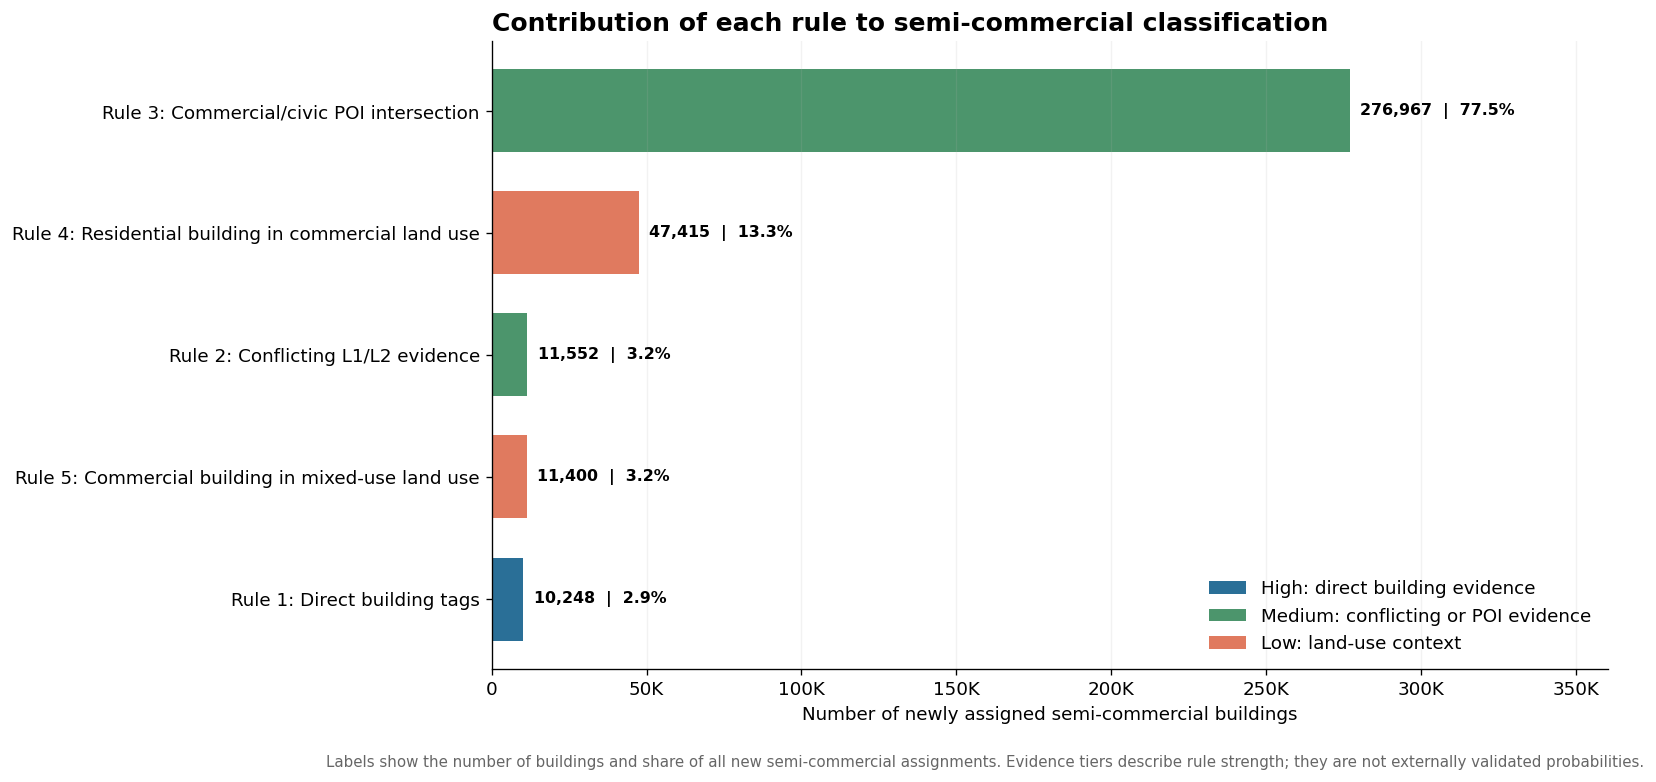

In [13]:
# ============================================================
# 3. CONTRIBUTION OF EACH CLASSIFICATION RULE
# ============================================================

section("2. CONTRIBUTION OF EACH CLASSIFICATION RULE")

print(rule_summary.to_string(formatters={
    "count": lambda x: f"{int(x):,}",
    "share_of_total_sc_pct": lambda x: f"{x:.2f}%",
    "share_of_new_sc_pct": lambda x: f"{x:.2f}%"
}))

print("\nDetailed rule-source distribution\n" + "-" * 100)
print_distribution(new_sc["rule_source"], "Detailed rule-source distribution", "buildings")

# CHART 1: rule contribution
plot_rules = rule_summary.drop(index="Existing", errors="ignore").sort_values("count")
labels = [f"{idx}: {row['description']}" for idx, row in plot_rules.iterrows()]
colors = [
    COLORS["high"] if row["evidence_tier"] == "High"
    else COLORS["medium"] if row["evidence_tier"] == "Medium"
    else COLORS["low"]
    for _, row in plot_rules.iterrows()
]

fig, ax = plt.subplots(figsize=(12, 6.8))
bars = ax.barh(labels, plot_rules["count"], color=colors, height=0.68)
add_bar_labels(ax, bars, plot_rules["count"], plot_rules["share_of_new_sc_pct"], plot_rules["count"].max())
ax.set_xlabel("Number of newly assigned semi-commercial buildings")
ax.xaxis.set_major_formatter(FuncFormatter(compact_number))
ax.set_title("Contribution of each rule to semi-commercial classification", loc="left")
ax.set_xlim(0, plot_rules["count"].max() * 1.30)
ax.grid(axis="x", alpha=0.16)
ax.legend(handles=[
    Patch(facecolor=COLORS["high"], label="High: direct building evidence"),
    Patch(facecolor=COLORS["medium"], label="Medium: conflicting or POI evidence"),
    Patch(facecolor=COLORS["low"], label="Low: land-use context")
], loc="lower right")
fig.text(
    0.01, -0.01,
    "Labels show the number of buildings and share of all new semi-commercial assignments. "
    "Evidence tiers describe rule strength; they are not externally validated probabilities.",
    fontsize=9, color="#666666"
)

# ===============


3. FINAL SEMI-COMMERCIAL SUBTYPE DISTRIBUTION
                            count share_pct
resolved_subtype                           
residential_retail        118,255    32.73%
residential_food_drink     75,231    20.82%
residential_civic          63,272    17.51%
residential_other_service  42,139    11.66%
residential_commercial     40,101    11.10%
residential_office         18,811     5.21%
residential_accommodation   3,486     0.96%


Text(0.01, -0.01, 'Each label shows the number of buildings and its share of the final semi-commercial dataset.')

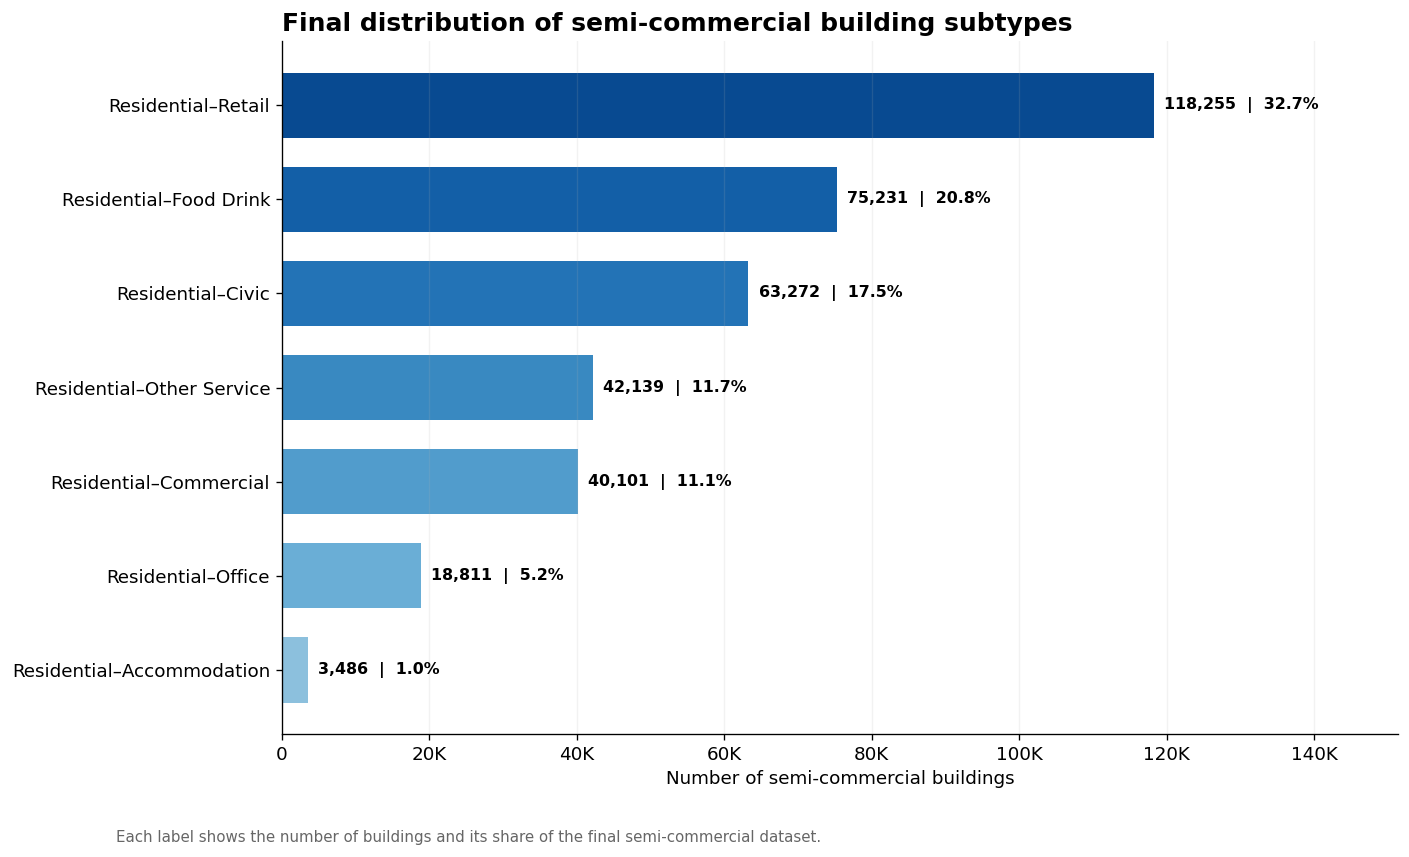

In [14]:
# 4. FINAL SEMI-COMMERCIAL SUBTYPE DISTRIBUTION
# ============================================================

section("3. FINAL SEMI-COMMERCIAL SUBTYPE DISTRIBUTION")

print(subtype_summary.to_string(formatters={
    "count": lambda x: f"{int(x):,}",
    "share_pct": lambda x: f"{x:.2f}%"
}))

# CHART 2: final subtype distribution
plot_subtypes = subtype_summary.sort_values("count")
labels = [clean_subtype(x) for x in plot_subtypes.index]

fig, ax = plt.subplots(figsize=(12, 7.5))
bars = ax.barh(
    labels, plot_subtypes["count"],
    color=plt.colormaps["Blues"](np.linspace(0.42, 0.90, len(plot_subtypes))),
    height=0.70
)
add_bar_labels(ax, bars, plot_subtypes["count"], plot_subtypes["share_pct"], plot_subtypes["count"].max())
ax.set_xlabel("Number of semi-commercial buildings")
ax.xaxis.set_major_formatter(FuncFormatter(compact_number))
ax.set_title("Final distribution of semi-commercial building subtypes", loc="left")
ax.set_xlim(0, plot_subtypes["count"].max() * 1.28)
ax.grid(axis="x", alpha=0.16)
fig.text(
    0.01, -0.01,
    "Each label shows the number of buildings and its share of the final semi-commercial dataset.",
    fontsize=9, color="#666666"
)



4. RULE-BY-SUBTYPE DISTRIBUTION

Counts
----------------------------------------------------------------------------------------------------
resolved_subtype  residential_accommodation  residential_civic  residential_commercial  residential_food_drink  residential_office  residential_other_service  residential_retail
rule_group                                                                                                                                                                       
Rule 1                                    0                  0                    3303                       0                3659                          0                3286
Rule 2                                 1543               5859                     714                    2088                 557                         60                 731
Rule 3                                 1441              57085                    1152                   72656               13129                

Text(0.0, 1.0, 'Dependence of each semi-commercial subtype on the classification rules')

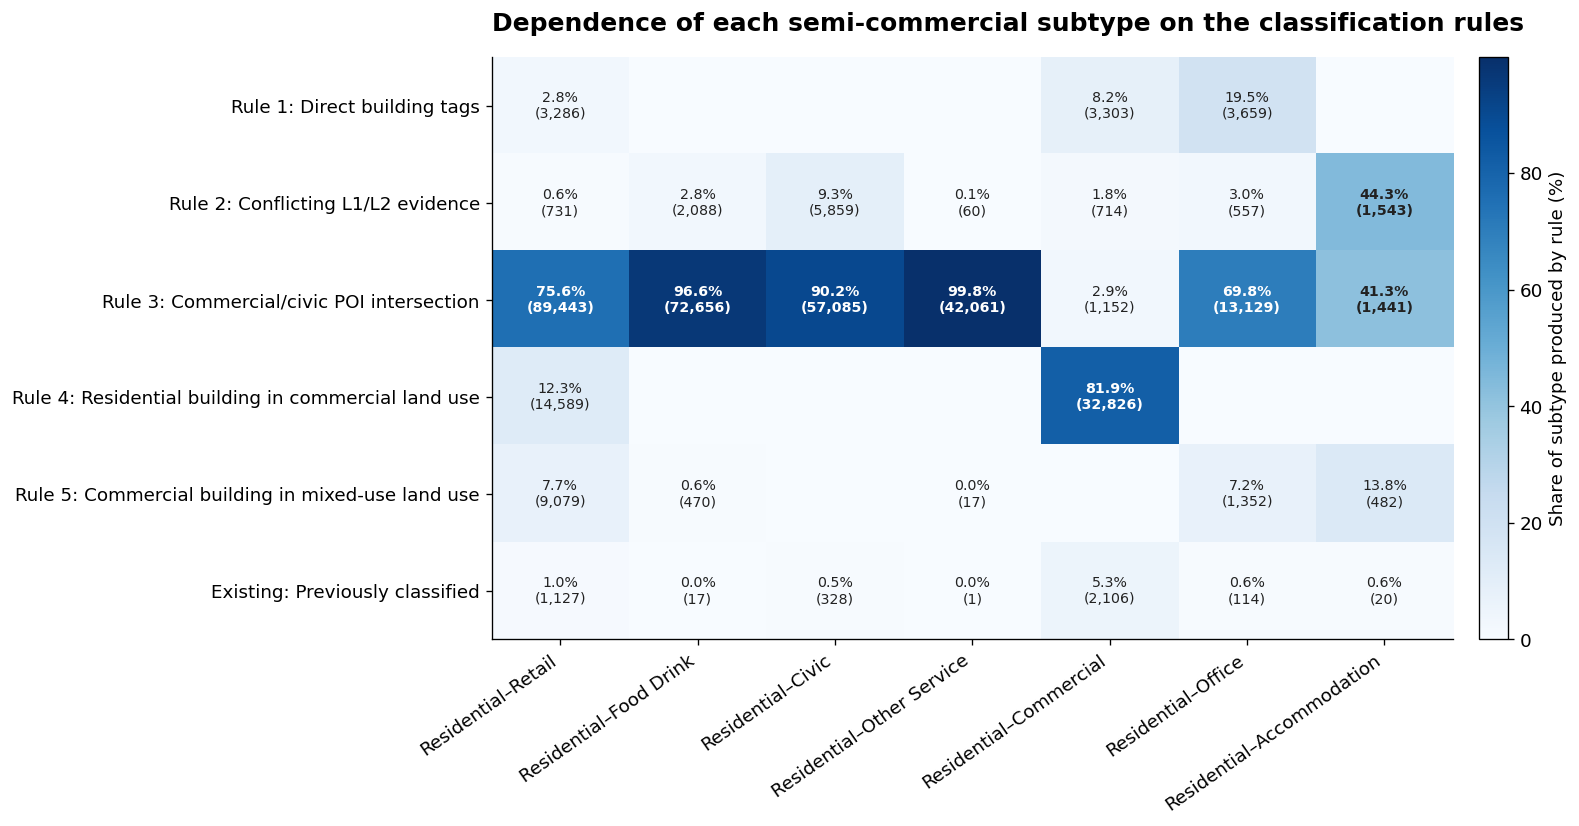

In [15]:

# ============================================================
# 5. WHICH RULE PRODUCED EACH SUBTYPE?
# ============================================================

section("4. RULE-BY-SUBTYPE DISTRIBUTION")

print("\nCounts\n" + "-" * 100)
print(rule_subtype_counts.to_string())

print("\nShare of each subtype contributed by each rule (%)\n" + "-" * 100)
print(rule_subtype_pct.to_string(float_format=lambda x: f"{x:.1f}%"))

# CHART 3: column-normalised heatmap
heat_counts = rule_subtype_counts.copy()
heat_pct = rule_subtype_pct.copy()
subtype_order = subtype_summary.index.tolist()
heat_counts = heat_counts.reindex(columns=subtype_order, fill_value=0)
heat_pct = heat_pct.reindex(columns=subtype_order, fill_value=0)

fig, ax = plt.subplots(figsize=(max(11, len(subtype_order) * 1.35), 6.3))
image = ax.imshow(heat_pct.values, aspect="auto", cmap="Blues", vmin=0, vmax=max(heat_pct.values.max(), 1))
ax.set_xticks(np.arange(len(subtype_order)), [clean_subtype(x) for x in subtype_order], rotation=35, ha="right")
ax.set_yticks(np.arange(len(heat_pct.index)), [f"{x}: {RULE_LABELS.get(x, x)}" for x in heat_pct.index])

threshold = heat_pct.values.max() * 0.50
for i in range(heat_pct.shape[0]):
    for j in range(heat_pct.shape[1]):
        pct = heat_pct.iat[i, j]
        count = heat_counts.iat[i, j]
        if count:
            ax.text(
                j, i, f"{pct:.1f}%\n({count:,.0f})",
                ha="center", va="center",
                fontsize=8.5, color="white" if pct > threshold else "#222222",
                fontweight="bold" if pct >= 20 else "normal"
            )

cbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.025)
cbar.set_label("Share of subtype produced by rule (%)")
ax.set_title("Dependence of each semi-commercial subtype on the classification rules", loc="left", pad=16)


In [16]:

# ============================================================
# 6. EVIDENCE-TIER SUMMARY
# ============================================================

section("5. EVIDENCE-TIER SUMMARY")

tier_order = ["High", "Medium", "Low", "Existing", "Unknown"]
tier_counts = sc["evidence_tier"].value_counts().reindex(tier_order, fill_value=0)
tier_counts = tier_counts[tier_counts > 0]
tier_table = pd.DataFrame({
    "count": tier_counts,
    "share_pct": tier_counts / len(sc) * 100
})

print(tier_table.to_string(formatters={
    "count": lambda x: f"{int(x):,}",
    "share_pct": lambda x: f"{x:.2f}%"
}))

print(
    "\nInterpretation:\n"
    "- High: direct shop, office or craft evidence on the building.\n"
    "- Medium: conflicting tags or a commercial/civic POI inside the building.\n"
    "- Low: classification based only on surrounding land-use context.\n"
    "- Existing: semi-commercial classification already present before these rules."
)

# No separate chart: the rule-contribution chart already communicates these tiers.



5. EVIDENCE-TIER SUMMARY
                count share_pct
evidence_tier                  
High           10,248     2.84%
Medium        288,519    79.86%
Low            58,815    16.28%
Existing        3,713     1.03%

Interpretation:
- High: direct shop, office or craft evidence on the building.
- Medium: conflicting tags or a commercial/civic POI inside the building.
- Low: classification based only on surrounding land-use context.
- Existing: semi-commercial classification already present before these rules.


In [17]:

# ============================================================
# 8. DATA-QUALITY AND ACCOUNTING CHECKS
# ============================================================

section("7. DATA-QUALITY AND ACCOUNTING CHECKS")

new_rule_records = gdf_bldg["rule_source"].notna().sum()
new_sc_final = mask_new_sc.sum()
new_not_final_sc = (gdf_bldg["rule_source"].notna() & ~gdf_bldg["final_l1"].eq("semi_commercial")).sum()
missing_new_subtype = (
    gdf_bldg["rule_source"].notna()
    & gdf_bldg["semi_commercial_type"].isna()
).sum()

print(f"Records with a new rule_source                     : {new_rule_records:,}")
print(f"New-rule records with final_l1=semi_commercial     : {new_sc_final:,}")
print(f"New-rule records not marked semi_commercial        : {new_not_final_sc:,}")
print(f"New-rule records missing semi_commercial_type      : {missing_new_subtype:,}")
print(f"Final semi-commercial records missing final_l2     : {sc['final_l2'].isna().sum():,}")
print(f"Duplicate building indexes                         : {gdf_bldg.index.duplicated().sum():,}")
print(f"Invalid residential_nan subtype records            : {residential_nan:,}")

if new_not_final_sc or missing_new_subtype or sc["final_l2"].isna().sum() or residential_nan:
    print("\nWARNING: One or more accounting checks failed. Review the corrected Rule 5 and final_l2 update cells.")
else:
    print("\nAll semi-commercial accounting checks passed.")

# ============================================================
# 9. FINAL REPORTING TABLE
# ============================================================

section("8. FINAL REPORTING TABLE")

final_report = pd.DataFrame({
    "Metric": [
        "Total buildings",
        "New semi-commercial assignments",
        "Previously existing semi-commercial records",
        "Total final semi-commercial buildings",
        "Semi-commercial share of all buildings",
        "High-evidence assignments",
        "Medium-evidence assignments",
        "Low-evidence assignments",
        "Unresolved final subtypes",
        "Invalid residential_nan records"
    ],
    "Value": [
        f"{len(gdf_bldg):,}",
        f"{len(new_sc):,}",
        f"{len(existing_sc):,}",
        f"{len(sc):,}",
        f"{len(sc) / len(gdf_bldg) * 100:.3f}%",
        f"{tier_counts.get('High', 0):,}",
        f"{tier_counts.get('Medium', 0):,}",
        f"{tier_counts.get('Low', 0):,}",
        f"{sc['resolved_subtype'].eq('unresolved').sum():,}",
        f"{residential_nan:,}"
    ]
})

print(final_report.to_string(index=False))



7. DATA-QUALITY AND ACCOUNTING CHECKS
Records with a new rule_source                     : 357,582
New-rule records with final_l1=semi_commercial     : 357,582
New-rule records not marked semi_commercial        : 0
New-rule records missing semi_commercial_type      : 0
Final semi-commercial records missing final_l2     : 0
Duplicate building indexes                         : 0
Invalid residential_nan subtype records            : 0

All semi-commercial accounting checks passed.

8. FINAL REPORTING TABLE
                                     Metric      Value
                            Total buildings 38,802,372
            New semi-commercial assignments    357,582
Previously existing semi-commercial records      3,713
      Total final semi-commercial buildings    361,295
     Semi-commercial share of all buildings     0.931%
                  High-evidence assignments     10,248
                Medium-evidence assignments    288,519
                   Low-evidence assignments     58,